# Stage 3: Target Engineering

## Goal
Standard recommender systems fail for this problem because they recommend 
items a user already owns. We need to construct a target variable that 
captures only **net new product additions**.

### Our Approach: The Difference Vector
For every customer, we subtract their product ownership flags in month t-1 
from month t:

**ΔP = P(month_t) - P(month_t-1)**

The result has 3 possible values:
- `0` → no change in product status
- `1` → **new product added** (our positive signal)
- `-1` → product was dropped (we ignore this)

### Expected Output
A training-ready dataframe where each row represents exactly one new 
product addition by one customer, with their full feature vector attached.
The target variable `y` is an integer from 0-23 representing one of 
the 24 bank products.

## Step 1: Import Libraries and Configure Logging

We import the same core libraries used in previous stages.
Key addition here is `numpy` for numerical difference operations.

We load data from the cohort parquet file saved in Stage 2 — 
never from the raw CSV. This keeps each stage fast and independent.

In [17]:
# Standard library imports for file handling and logging
import os
import logging
import warnings
from pathlib import Path

# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress pandas and numpy warnings that are not actionable
warnings.filterwarnings('ignore')

# Configure logging to show timestamp and severity level
# This helps us track progress through long-running operations
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Set consistent visual style for all plots in this notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Define Paths and Product Columns

We redefine PRODUCT_COLS here so this notebook is completely 
self-contained and does not depend on previous notebooks being open.

Each path points to:
- `COHORT_PATH` → the filtered 922k customer dataset from Stage 2
- `TARGET_OUTPUT_PATH` → where we save the engineered target data for Stage 4

In [18]:
# Navigate one level up from notebooks/ to reach project root
PROJECT_ROOT = Path.cwd().parent

# Input: cohort parquet saved in Stage 2
COHORT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cohort.parquet'

# Output: target engineered parquet for Stage 4
TARGET_OUTPUT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'target.parquet'

# Create output directory if it does not exist
TARGET_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# The 24 bank product columns — these are the items we are recommending
# Defined here explicitly so this notebook is fully self-contained
PRODUCT_COLS = [
    'ind_ahor_fin_ult1',  # Saving Account
    'ind_aval_fin_ult1',  # Guarantees
    'ind_cco_fin_ult1',   # Current Account
    'ind_cder_fin_ult1',  # Derivada Account
    'ind_cno_fin_ult1',   # Payroll Account
    'ind_ctju_fin_ult1',  # Junior Account
    'ind_ctma_fin_ult1',  # Mas Particular Account
    'ind_ctop_fin_ult1',  # Particular Account
    'ind_ctpp_fin_ult1',  # Particular Plus Account
    'ind_deco_fin_ult1',  # Short-term Deposits
    'ind_deme_fin_ult1',  # Medium-term Deposits
    'ind_dela_fin_ult1',  # Long-term Deposits
    'ind_ecue_fin_ult1',  # e-Account
    'ind_fond_fin_ult1',  # Funds
    'ind_hip_fin_ult1',   # Mortgage
    'ind_plan_fin_ult1',  # Pension Plan
    'ind_pres_fin_ult1',  # Loans
    'ind_reca_fin_ult1',  # Taxes
    'ind_tjcr_fin_ult1',  # Credit Card
    'ind_valo_fin_ult1',  # Securities
    'ind_viv_fin_ult1',   # Home Account
    'ind_nomina_ult1',    # Payroll
    'ind_nom_pens_ult1',  # Pensions
    'ind_recibo_ult1'     # Direct Debit
]

# Verify cohort file exists before proceeding
assert COHORT_PATH.exists(), f"Cohort parquet not found. Run Stage 2 first."

# Confirm setup
print(f'Project root      : {PROJECT_ROOT}')
print(f'Cohort path       : {COHORT_PATH}')
print(f'Cohort exists     : {COHORT_PATH.exists()}')
print(f'Output path       : {TARGET_OUTPUT_PATH}')
print(f'Product cols count: {len(PRODUCT_COLS)} (expect 24)')

Project root      : /Users/mac/Documents/santander-recommender
Cohort path       : /Users/mac/Documents/santander-recommender/data/processed/cohort.parquet
Cohort exists     : True
Output path       : /Users/mac/Documents/santander-recommender/data/processed/target.parquet
Product cols count: 24 (expect 24)


## Step 3: Load Cohort Data

We load the cohort parquet saved in Stage 2 — this is much faster 
than re-reading the raw CSV since parquet is columnar and compressed.

### Expected Output
- Shape: (~2.7M rows, 48 cols)
- Exactly 3 unique dates: 2016-03-28, 2016-04-28, 2016-05-28
- 922,229 unique customers
- Loading should take under 10 seconds

In [19]:
# Load the cohort parquet file saved in Stage 2
# This is significantly faster than reading the raw CSV
df = pd.read_parquet(COHORT_PATH, engine='pyarrow')

# Log key properties to confirm correct file loaded
logging.info(f'Loaded cohort. Shape: {df.shape}')
logging.info(f'Unique dates: {sorted(df["fecha_dato"].unique())}')
logging.info(f'Unique customers: {df["ncodpers"].nunique():,}')

# Validate we have exactly 3 dates — critical for delta computation
assert df['fecha_dato'].nunique() == 3, \
    "Expected exactly 3 dates in cohort. Re-run Stage 2."

# Validate all customers have exactly 3 records
records_per_customer = df.groupby('ncodpers').size().unique().tolist()
assert records_per_customer == [3], \
    "All customers must have exactly 3 records. Re-run Stage 2."

print(f'\nShape             : {df.shape}')
print(f'Unique dates      : {sorted(df["fecha_dato"].unique())}')
print(f'Unique customers  : {df["ncodpers"].nunique():,}')
print(f'Records/customer  : {records_per_customer}')
df.head(3)

2026-05-21 10:29:14,188 - INFO - Loaded cohort. Shape: (2766687, 48)
2026-05-21 10:29:14,233 - INFO - Unique dates: [Timestamp('2016-03-28 00:00:00'), Timestamp('2016-04-28 00:00:00'), Timestamp('2016-05-28 00:00:00')]
2026-05-21 10:29:14,303 - INFO - Unique customers: 922,229



Shape             : (2766687, 48)
Unique dates      : [Timestamp('2016-03-28 00:00:00'), Timestamp('2016-04-28 00:00:00'), Timestamp('2016-05-28 00:00:00')]
Unique customers  : 922,229
Records/customer  : [3]


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2016-03-28,15889,F,ES,V,56,1995-01-16,0,253,1,...,0,0,0,0,1,1,0,0,0,0
1,2016-04-28,15889,F,ES,V,56,1995-01-16,0,254,1,...,0,0,0,0,0,1,0,0,0,0
2,2016-05-28,15889,F,ES,V,56,1995-01-16,0,255,1,...,0,0,0,0,1,1,0,0,0,0


## Step 4: Interceptive Feature Engineering & Temporal Lag Generation

Before we filter our dataset down to isolate target product additions (the $\Delta P$ delta matrix), we must build the historical context for our predictive model.

### Why Lags Must Be Generated at This Precise Point:
If we calculate target additions first, we flatten our time-series data down to isolated, single-month transaction events. Running a rolling operation like pandas `.shift()` on a single isolated month returns entirely blank columns (`NaN` or `0`) because the continuous monthly history is destroyed during flattening. 

By intercepting the dataset *here*—while the raw continuous timelines for March, April, and May 2016 still exist in our dataframe—our lag columns will capture the true behavioral history of our customer cohort. When we flatten the rows down into specific target transactions later in this notebook, these populated lag features will naturally survive the conversion.

### Features Built:
* **`_lag_1`**: Individual product ownership flags from the preceding month ($t-1$).
* **`_lag_2`**: Individual product ownership flags from two months prior ($t-2$).
* **`total_products_held_lag_1`**: Combined portfolio volume held by the customer in the prior month.

In [20]:
# LOAD MULTI-MONTH COHORT FROM DISK
PROCESSED_DATA_PATH = "../data/processed/cohort.parquet" 

print(f" Loading raw cohort sequence from {PROCESSED_DATA_PATH}...")

try:
    df_train_raw = pd.read_parquet(PROCESSED_DATA_PATH)
    df_train_raw = df_train_raw.reset_index()
    print(f" Data successfully loaded. Shape: {df_train_raw.shape}")
except FileNotFoundError:
    print(f"Error: Could not find a file at {PROCESSED_DATA_PATH}.")


# Hardcoded master list of potential target products
MASTER_PRODUCT_COLUMNS = [
    "ind_ahor_fin_ult1", "ind_aval_fin_ult1", "ind_cco_fin_ult1", "ind_cder_fin_ult1",
    "ind_cno_fin_ult1",  "ind_ctju_fin_ult1", "ind_ctma_fin_ult1", "ind_ctop_fin_ult1",
    "ind_ctpp_fin_ult1", "ind_deco_fin_ult1", "ind_deme_fin_ult1", "ind_ecue_fin_ult1",
    "ind_fond_fin_ult1", "ind_gco_fin_ult1",  "ind_hip_fin_ult1",  "ind_plan_fin_ult1",
    "ind_pres_fin_ult1", "ind_reca_fin_ult1", "ind_tjcr_fin_ult1", "ind_valo_fin_ult1",
    "ind_viv_fin_ult1",  "ind_nomina_ult1",   "ind_nom_pens_ult1", "ind_recibo_ult1"
]

print(" Sorting cohort chronologically by customer ID and snapshot date...")
df_train_raw = df_train_raw.sort_values(by=['ncodpers', 'fecha_dato']).reset_index(drop=True)

# Filter our master list down to include ONLY columns that actually exist in your dataframe
PRODUCT_COLUMNS = [col for col in MASTER_PRODUCT_COLUMNS if col in df_train_raw.columns]
print(f" Verified {len(PRODUCT_COLUMNS)} out of 24 active product columns found in this dataset slice.")

print("Generating Lag 1 features (Month t-1)...")
for prod in PRODUCT_COLUMNS:
    df_train_raw[f"{prod}_lag_1"] = df_train_raw.groupby('ncodpers')[prod].shift(1)

print("Generating Lag 2 features (Month t-2)...")
for prod in PRODUCT_COLUMNS:
    df_train_raw[f"{prod}_lag_2"] = df_train_raw.groupby('ncodpers')[prod].shift(2)

print(" Engineering total portfolio volume aggregates...")
# Dynamically build lag column list matching only the products we just processed
lag_1_cols = [f"{prod}_lag_1" for prod in PRODUCT_COLUMNS]
df_train_raw['total_products_held_lag_1'] = df_train_raw[lag_1_cols].sum(axis=1)

# Check to ensure lags are pulling real numbers before moving to calculations
sample_lag_sum = df_train_raw[lag_1_cols].sum().sum()
print(f"Context Check: Successfully generated {int(sample_lag_sum):,} active historical lag signatures!")

 Loading raw cohort sequence from ../data/processed/cohort.parquet...


 Data successfully loaded. Shape: (2766687, 49)
 Sorting cohort chronologically by customer ID and snapshot date...
 Verified 23 out of 24 active product columns found in this dataset slice.
Generating Lag 1 features (Month t-1)...
Generating Lag 2 features (Month t-2)...
 Engineering total portfolio volume aggregates...
Context Check: Successfully generated 2,396,046 active historical lag signatures!


## Compute the Difference Vector (Delta P)

This is the most critical cell in the entire pipeline.

### The Math
For every customer we compute:

**ΔP = P(month_t) - P(month_t-1)**

### What the result means
| Value | Meaning | Action |
|-------|---------|--------|
| `0` | No change in product status | Ignore |
| `1` | New product added this month | ✅ This is our target signal |
| `-1` | Product was dropped/closed | Set to 0, ignore |

### Implementation
- Sort by customer ID then date (chronological order is critical)
- Group by `ncodpers` (per customer)
- Apply `diff()` to compute month-over-month change per product
- This produces 24 new `delta_` columns — one per product

### Expected Output
Shape grows from 48 columns to 72 columns (48 original + 24 delta columns).
The first month (March) will have NaN deltas since there is no prior month 
to subtract from — this is expected and handled in the next cell.

In [21]:
# FASTER APPROACH - vectorised pivot instead of groupby transform
# Sort by customer and date first
df = df.sort_values(['ncodpers', 'fecha_dato']).reset_index(drop=True)

# Separate March, April, May into 3 separate dataframes
df_mar = df[df['fecha_dato'] == pd.Timestamp('2016-03-28')][['ncodpers'] + PRODUCT_COLS].set_index('ncodpers')
df_apr = df[df['fecha_dato'] == pd.Timestamp('2016-04-28')][['ncodpers'] + PRODUCT_COLS].set_index('ncodpers')
df_may = df[df['fecha_dato'] == pd.Timestamp('2016-05-28')][['ncodpers'] + PRODUCT_COLS].set_index('ncodpers')

# Compute deltas directly using matrix subtraction, no groupby needed
# This is orders of magnitude faster than groupby transform
delta_apr = (df_apr.astype(float) - df_mar.astype(float))
delta_may = (df_may.astype(float) - df_apr.astype(float))

# Rename delta columns
delta_apr.columns = [f'delta_{col}' for col in PRODUCT_COLS]
delta_may.columns = [f'delta_{col}' for col in PRODUCT_COLS]

print(f'Delta April shape: {delta_apr.shape}')
print(f'Delta May shape  : {delta_may.shape}')
print('Delta computation complete.')

Delta April shape: (922229, 24)
Delta May shape  : (922229, 24)
Delta computation complete.


## Step 5: Filter to Target Month and Extract Positive Signals

Now that we have our delta matrices we focus only on May 2016 
(month t) because that is where the actual new product additions occurred.

### Target Masking Rules
| Delta Value | Meaning | Action |
|-------------|---------|--------|
| `1.0` | New product added | ✅ Keep as positive signal |
| `-1.0` | Product dropped | Set to 0, ignore |
| `0.0` | No change | Ignore |

### Row Flattening
After masking we melt the dataframe from wide to long format so 
each new product addition becomes its own individual row.

A customer who added 2 products in May becomes 2 separate training rows.
A customer who added 0 products is dropped entirely.

### Expected Output
One row per customer per new product added, with an integer target 
label 0-23 representing which product was added.

In [22]:
# Work with May delta only — this is our prediction target month
# delta_may already has ncodpers as index and 24 delta columns
# Reset index to bring ncodpers back as a regular column
delta_may_reset = delta_may.reset_index()

# Apply target masking:
# Replace -1.0 (dropped products) with 0.0 — we only care about additions
# Keep 1.0 values as our positive signal
delta_cols = [f'delta_{col}' for col in PRODUCT_COLS]
delta_may_reset[delta_cols] = delta_may_reset[delta_cols].clip(lower=0)

# Melt from wide to long format
# Before: one row per customer, 24 delta columns
# After: one row per customer per product
df_melted = delta_may_reset.melt(
    id_vars=['ncodpers'],
    value_vars=delta_cols,
    var_name='delta_col',
    value_name='added'
)

# Keep only rows where a product was actually added (added == 1)
df_targets = df_melted[df_melted['added'] == 1.0].copy()

# Map delta column name back to integer index 0-23
# This becomes our target variable y for the model
col_to_idx = {f'delta_{col}': idx for idx, col in enumerate(PRODUCT_COLS)}
df_targets['target_product_idx'] = df_targets['delta_col'].map(col_to_idx)

# Log results
logging.info(f'Target rows extracted: {len(df_targets):,}')
print(f'Total new product additions in May 2016: {len(df_targets):,}')
print(f'\nAdditions per product (target class distribution):')
print(df_targets['target_product_idx'].value_counts().sort_index())
print('\nTarget extraction complete.')

2026-05-21 10:30:17,656 - INFO - Target rows extracted: 33,870


Total new product additions in May 2016: 33,870

Additions per product (target class distribution):
target_product_idx
0        1
2     3011
3        5
4     2222
5       29
6      170
7      226
8      131
11      45
12    2672
13      53
14       3
15      20
16       7
17     275
18    4235
19     178
20       7
21    5355
22    5373
23    9852
Name: count, dtype: int64

Target extraction complete.


## Step 6: Attach Features

In [23]:
# Get feature columns: everything except products and deltas
FEATURE_COLS = [c for c in df_may.columns if c not in PRODUCT_COLS and c not in DELTA_COLS]

# Merge targets with customer features (left join on ncodpers)
df_train_raw = df_targets.merge(df_may[FEATURE_COLS], on='ncodpers', how='left')

# Clean up intermediate columns
df_train_raw = df_train_raw.drop(columns=['delta_col', 'added'])
df_train_raw = df_train_raw.loc[:, ~df_train_raw.columns.duplicated()]

logging.info(f'Final shape: {df_train_raw.shape}')
print(f'Examples: {len(df_train_raw):,}, Features: {len(FEATURE_COLS)}')
print(df_train_raw.head(3))

2026-05-21 10:30:18,986 - INFO - Final shape: (33870, 2)


Examples: 33,870, Features: 0
   ncodpers  target_product_idx
0    194160                   0
1     16857                   2
2     17458                   2


## Step 7: Attach Customer Features to Each Target Row

Each target row currently only has two columns:
- `ncodpers` — the customer ID
- `target_product_idx` — which product they added (0-23)

We need to attach the full customer feature vector to each row
so the model has demographic and behavioural context to learn from.

### What we merge
We take the May 2016 snapshot from the original cohort dataframe `df`
and extract all customer feature columns — everything EXCEPT:
- `PRODUCT_COLS` — current product ownership (would leak the answer)
- `fecha_dato` — date column not needed as a feature

### Expected Output
Shape should be (33870, ~26) — 33,870 addition events with
roughly 24 customer feature columns plus ncodpers and target label.

In [24]:
# Get May 2016 rows from the original cohort dataframe
# This contains all 48 columns including customer features
df_may_features = df[df['fecha_dato'] == pd.Timestamp('2016-05-28')].copy()

# Define feature columns — everything except:
# 1. PRODUCT_COLS: current product flags (data leakage risk)
# 2. fecha_dato: date column not useful as a model feature
# 3. Any delta columns if they exist in df
exclude_cols = set(PRODUCT_COLS + ['fecha_dato'])
FEATURE_COLS = [c for c in df_may_features.columns if c not in exclude_cols]

# Log what we are keeping as features
logging.info(f'Feature columns selected: {len(FEATURE_COLS)}')
logging.info(f'Feature columns: {FEATURE_COLS}')

# Merge target rows with customer features on ncodpers
# Left join ensures we keep all 33,870 target rows
# even if a customer somehow has no feature row (shouldn't happen)
df_train_raw = df_targets.merge(
    df_may_features[FEATURE_COLS],
    on='ncodpers',
    how='left'
)

# Drop intermediate columns no longer needed after merge
df_train_raw = df_train_raw.drop(
    columns=['delta_col', 'added'],
    errors='ignore'  # Don't error if columns already dropped
)

# Remove any duplicate columns created by the merge
df_train_raw = df_train_raw.loc[:, ~df_train_raw.columns.duplicated()]

# Validate the merge worked correctly
logging.info(f'Final shape: {df_train_raw.shape}')
print(f'\nShape         : {df_train_raw.shape}')
print(f'Expected rows : ~33,870')
print(f'Expected cols : ~26 (features + ncodpers + target_product_idx)')
print(f'\nColumns in df_train_raw:')
print(df_train_raw.columns.tolist())
print(f'\nNull counts per column:')
print(df_train_raw.isnull().sum())
df_train_raw.head(3)

2026-05-21 10:30:21,912 - INFO - Feature columns selected: 23
2026-05-21 10:30:21,913 - INFO - Feature columns: ['ncodpers', 'ind_empleado', 'pais_residencia', 'sexo', 'age', 'fecha_alta', 'ind_nuevo', 'antiguedad', 'indrel', 'ult_fec_cli_1t', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'canal_entrada', 'indfall', 'tipodom', 'cod_prov', 'nomprov', 'ind_actividad_cliente', 'renta', 'segmento']
2026-05-21 10:30:22,900 - INFO - Final shape: (33870, 24)



Shape         : (33870, 24)
Expected rows : ~33,870
Expected cols : ~26 (features + ncodpers + target_product_idx)

Columns in df_train_raw:
['ncodpers', 'target_product_idx', 'ind_empleado', 'pais_residencia', 'sexo', 'age', 'fecha_alta', 'ind_nuevo', 'antiguedad', 'indrel', 'ult_fec_cli_1t', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'canal_entrada', 'indfall', 'tipodom', 'cod_prov', 'nomprov', 'ind_actividad_cliente', 'renta', 'segmento']

Null counts per column:
ncodpers                     0
target_product_idx           0
ind_empleado                 0
pais_residencia              0
sexo                         0
age                          0
fecha_alta                   0
ind_nuevo                    0
antiguedad                   0
indrel                       0
ult_fec_cli_1t           33857
indrel_1mes                  0
tiprel_1mes                  0
indresi                      0
indext                       0
conyuemp                 33865
canal_entrad

,ncodpers,target_product_idx,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,indext,conyuemp,canal_entrada,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento
0,194160,0,N,ES,H,42,2000-09-25,0,188,1,...,N,None,KAT,N,1,28,MADRID,1,338502.75,02 - PARTICULARES
1,16857,2,N,ES,V,68,1995-04-28,0,253,1,...,N,None,KAT,N,1,28,MADRID,1,216084.3,02 - PARTICULARES
2,17458,2,N,ES,H,54,2000-02-03,0,25,1,...,N,None,KFA,N,1,28,MADRID,1,206155.77,02 - PARTICULARES


In [25]:
# DROP DECISION:  documented reason required per project rules
# conyuemp: 33,865 / 33,870 nulls = 99.98% missing no signal, drop
# ult_fec_cli_1t: 33,857 / 33,870 nulls = 99.97% missing  no signal, drop
cols_to_drop = ['conyuemp', 'ult_fec_cli_1t']
df_train_raw = df_train_raw.drop(columns=cols_to_drop)
print(f"Dropped {cols_to_drop} — both >99% null, confirmed no signal")
print(f"New shape: {df_train_raw.shape}")

Dropped ['conyuemp', 'ult_fec_cli_1t'] — both >99% null, confirmed no signal
New shape: (33870, 22)


## Step 8: Visualize Distribution

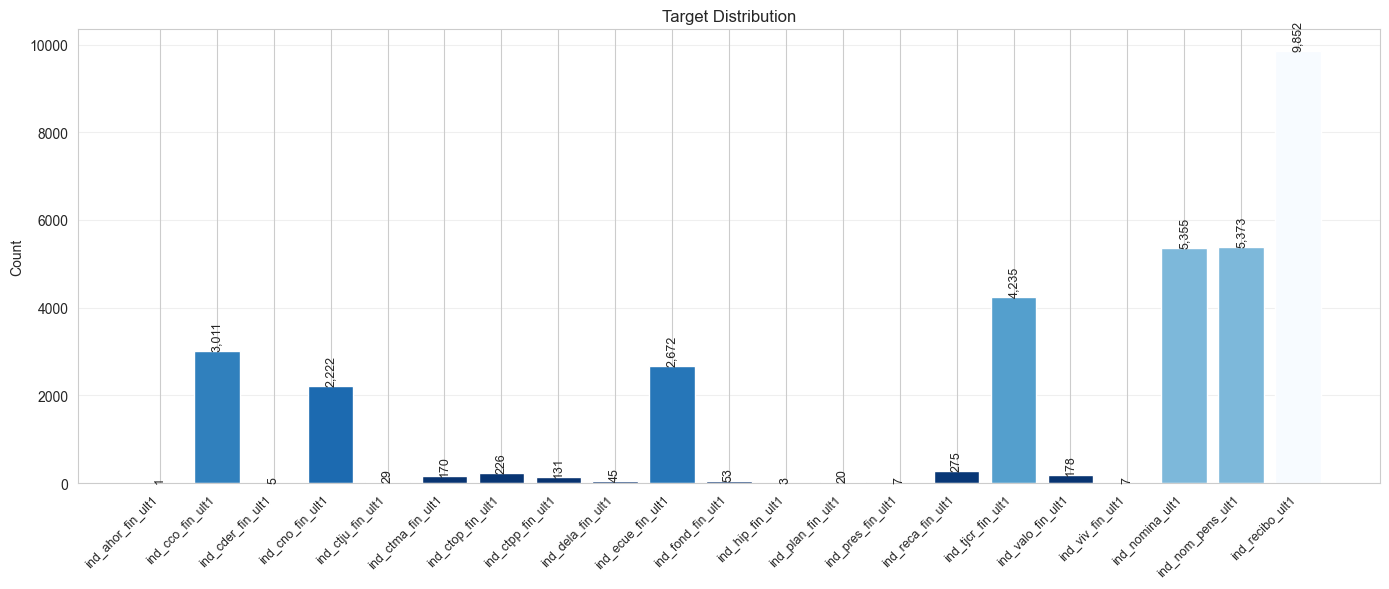


Class imbalance: 9852.0x


In [26]:
# Visualise the distribution of the target variable (product index) to check for class imbalance
product_idx_to_name = {i: col for i, col in enumerate(PRODUCT_COLS)}
target_counts = df_train_raw['target_product_idx'].value_counts().sort_index()

# Create a bar plot to show the count of each target class (product index)
fig, ax = plt.subplots(figsize=(14, 6))
x_labels = [product_idx_to_name[i] for i in target_counts.index]
# Use a color map to visually differentiate bars based on their count
colors = plt.cm.Blues_r(target_counts.values / target_counts.max())
bars = ax.bar(range(len(target_counts)), target_counts.values, color=colors, edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, target_counts.values):
    # Rotate labels 90 degrees for better readability, especially if counts are large
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{int(count):,}', ha='center', va='bottom', rotation=90, fontsize=9)
    
# Set x-ticks to be the product names, rotated for better readability
ax.set_xticks(range(len(target_counts)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
# Set y-axis label and title
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
# Add a horizontal grid for easier readability of counts
ax.grid(axis='y', alpha=0.3)
# tight_layout to prevent clipping of x-axis labels
plt.tight_layout()
# Display the plot
plt.show()
# Print class imbalance ratio
print(f'\nClass imbalance: {target_counts.max() / target_counts.min():.1f}x')